<a href="https://colab.research.google.com/github/DmitryTheSuslov/AHP_KIS/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 3
## Цепи Маркова и одноканальная СМО


## Задание 1. Модель деградации сервера (дискретная цепь Маркова)

Состояния: S1 (отличное), S2 (хорошее), S3 (удовлетворительное), S4 (критическое), S5 (профилактика), S6 (отказ).

In [ ]:
install.packages("queueing")
library(queueing)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Создаем матрицу 6x6 с нулями
P <- matrix(0, nrow = 6, ncol = 6)

# Заполняем вероятности переходов (сумма по каждой строке = 1)

# Из S1 (Отличное): индекс 1
P[1, 1] <- 0.7
P[1, 2] <- 0.25
P[1, 3] <- 0.05

# Из S2 (Хорошее): индекс 2
P[2, 2] <- 0.75
P[2, 3] <- 0.20
P[2, 4] <- 0.05

# Из S3 (Удовлетворительное): индекс 3
P[3, 3] <- 0.60
P[3, 4] <- 0.20
P[3, 5] <- 0.15
P[3, 6] <- 0.05

# Из S4 (Критическое): индекс 4
P[4, 4] <- 0.50
P[4, 5] <- 0.30
P[4, 6] <- 0.20

# Из S5 (Профилактика): индекс 5
P[5, 1] <- 0.85
P[5, 2] <- 0.15

# Из S6 (Отказ): индекс 6 (поглощающее состояние)
P[6, 6] <- 1.0

row_sums <- rowSums(P)
print("Суммы по строкам матрицы P:")
print(row_sums)

[1] "Суммы по строкам матрицы P:"
[1] 1 1 1 1 1 1


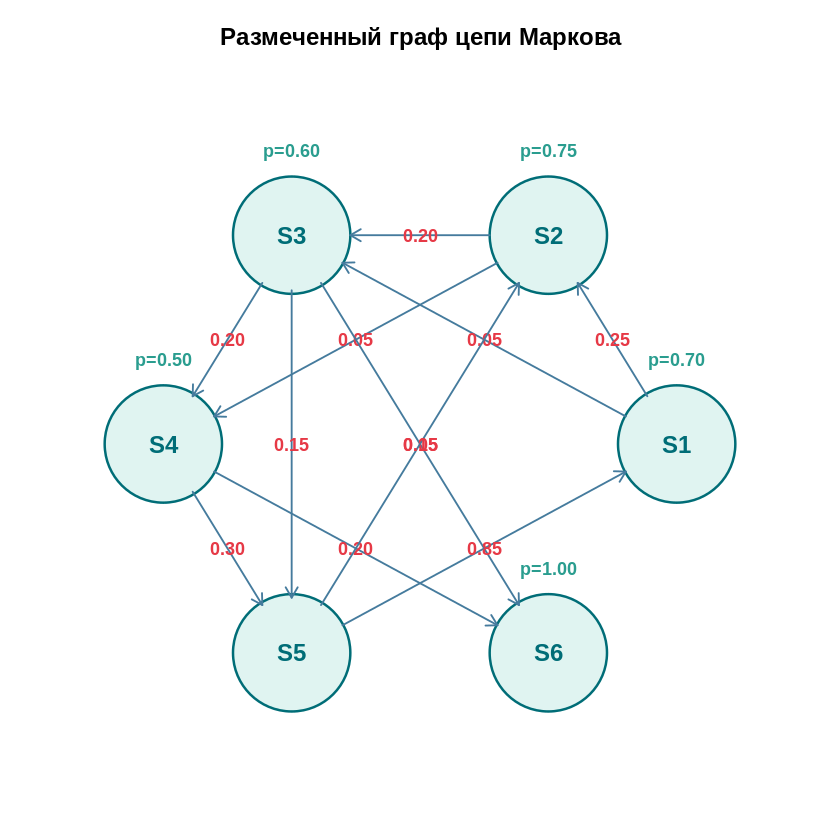

In [ ]:
par(mar = c(1, 1, 3, 1))

angles <- seq(0, 2*pi, length.out = 7)[-7]
coords <- cbind(0.5 + 0.35 * cos(angles), 0.5 + 0.35 * sin(angles))

plot(coords, type = 'n', xlim = c(0, 1), ylim = c(0, 1),
     axes = FALSE, xlab = '', ylab = '',
     main = 'Размеченный граф цепи Маркова')

# Кружки состояний
symbols(coords[,1], coords[,2], circles = rep(0.08, 6),
        inches = FALSE, add = TRUE,
        bg = '#e0f4f1', fg = '#006d77', lwd = 2)

# Подписи состояний
text(coords[,1], coords[,2], labels = paste0('S', 1:6),
     font = 2, cex = 1.2, col = '#006d77')

# Стрелки с вероятностями
for (i in 1:6) {
  for (j in 1:6) {
    if (i != j && P[i,j] > 0) {
      # Смещение для читаемости
      dx <- coords[j,1] - coords[i,1]
      dy <- coords[j,2] - coords[i,2]
      len <- sqrt(dx^2 + dy^2)
      dx <- dx/len * 0.08
      dy <- dy/len * 0.08

      arrows(coords[i,1] + dx, coords[i,2] + dy,
             coords[j,1] - dx, coords[j,2] - dy,
             length = 0.1, col = '#457b9d', lwd = 1.5)

      # Вероятность на стрелке
      mid_x <- (coords[i,1] + coords[j,1]) / 2
      mid_y <- (coords[i,2] + coords[j,2]) / 2
      text(mid_x, mid_y, labels = sprintf('%.2f', P[i,j]),
           cex = 0.9, col = '#e63946', font = 2)
    }
  }
}

# Self-переходы (петли)
for (i in 1:6) {
  if (P[i,i] > 0) {
    text(coords[i,1], coords[i,2] + 0.12,
         labels = sprintf('p=%.2f', P[i,i]),
         cex = 0.9, col = '#2a9d8f', font = 2)
  }
}

In [ ]:
# Начальный вектор: сервер новый, находится в S1
pi_0 <- c(1, 0, 0, 0, 0, 0)

# Выбираем k = 2 недели
k <- 2

# Названия состояний для вывода
state_names <- c("S1 Отличное", "S2 Хорошее", "S3 Удовл.",
                 "S4 Критич.", "S5 Профил.", "S6 Отказ")

print("Начальное распределение:")
print(pi_0)
cat("Параметр k =" , k)

[1] "Начальное распределение:"
[1] 1 0 0 0 0 0
Параметр k = 2

In [ ]:
# Функция для возведения матрицы в степень
matrix_power <- function(M, n) {
  if (n == 0) return(diag(nrow(M)))
  result <- M
  for (i in 2:n) {
    result <- result %*% M
  }
  return(result)
}

In [ ]:
# Вычисляем P^k, P^(2k), P^(4k)
P_k <- matrix_power(P, k)
P_2k <- matrix_power(P, 2*k)
P_4k <- matrix_power(P, 4*k)

# Вычисляем распределения вероятностей
pi_k <- pi_0 %*% P_k
pi_2k <- pi_0 %*% P_2k
pi_4k <- pi_0 %*% P_4k

# Вывод результатов
cat("Распределение через", k, "недели\n")
cat(round(pi_k, 4), "\n")

cat("Распределение через", 2*k, "недели\n")
cat(round(pi_2k, 4), "\n")

cat("Распределение через", 4*k, "недель\n")
cat(round(pi_4k, 4), "\n")

Распределение через 2 недели
0.49 0.3625 0.115 0.0225 0.0075 0.0025 
Распределение через 4 недели
0.265 0.3876 0.1962 0.0792 0.0406 0.0315 
Распределение через 8 недель
0.1881 0.2901 0.1929 0.1124 0.0642 0.1522 


In [ ]:
# эксперимент с красивым выводом

print_results <- function(pi_vec, weeks, state_names) {
  print(paste("========================================"))
  print(paste("Распределение после", weeks, "недель"))
  print(paste("========================================"))

  for (i in 1:length(state_names)) {
    prob <- pi_vec[i]
    bar <- paste(rep("█", round(prob * 50)), collapse = "")
    print(sprintf("%-15s: %.4f (%6.2f%%) %s",
                  state_names[i], prob, prob * 100, bar))
  }
  print(paste("Сумма:", sum(pi_vec)))
  print("")
}

print_results(pi_k, k, state_names)
print_results(pi_2k, 2*k, state_names)
print_results(pi_4k, 4*k, state_names)

[1] "========================================"
[1] "Распределение после 2 недель"
[1] "========================================"
[1] "S1 Отличное: 0.4900 ( 49.00%) ████████████████████████"
[1] "S2 Хорошее: 0.3625 ( 36.25%) ██████████████████"
[1] "S3 Удовл. : 0.1150 ( 11.50%) ██████"
[1] "S4 Критич.: 0.0225 (  2.25%) █"
[1] "S5 Профил.: 0.0075 (  0.75%) "
[1] "S6 Отказ  : 0.0025 (  0.25%) "
[1] "Сумма: 1"
[1] ""
[1] "========================================"
[1] "Распределение после 4 недель"
[1] "========================================"
[1] "S1 Отличное: 0.2650 ( 26.50%) █████████████"
[1] "S2 Хорошее: 0.3876 ( 38.76%) ███████████████████"
[1] "S3 Удовл. : 0.1962 ( 19.62%) ██████████"
[1] "S4 Критич.: 0.0792 (  7.92%) ████"
[1] "S5 Профил.: 0.0406 (  4.06%) ██"
[1] "S6 Отказ  : 0.0315 (  3.15%) ██"
[1] "Сумма: 1"
[1] ""
[1] "========================================"
[1] "Распределение после 8 недель"
[1] "========================================"
[1] "S1 Отличное: 0.1881 ( 18.81%) █

In [ ]:
# Вероятность работы без отказа 8 недель

weeks_8 <- 8
P_8 <- matrix_power(P, weeks_8)
pi_8 <- pi_0 %*% P_8

# Вероятность отказа = вероятность быть в S6
prob_failure_8 <- pi_8[6]

# Вероятность безотказной работы
prob_no_failure_8 <- 1 - prob_failure_8

cat("Вероятность безотказной работы через 8 недель\n")
cat("  Вероятность отказа (S6):", round(prob_failure_8, 4), "\n")
cat("  Вероятность без отказа: ", round(prob_no_failure_8, 4), "\n")

Вероятность безотказной работы через 8 недель
  Вероятность отказа (S6): 0.1522 
  Вероятность без отказа:  0.8478 


In [ ]:
# Среднее время до отказа (MTTF)

max_weeks <- 500  # максимальное число недель для суммирования

# Вычисляем вероятность выживания для каждой недели
survival_probs <- numeric(max_weeks)

for (n in 0:(max_weeks - 1)) {
  if (n == 0) {
    survival_probs[n + 1] <- 1  # в начале точно не в отказе
  } else {
    P_n <- matrix_power(P, n)
    pi_n <- pi_0 %*% P_n
    survival_probs[n + 1] <- 1 - pi_n[6]  # вероятность не быть в S6
  }
}

# MTTF = сумма вероятностей выживания
MTTF_numerical <- sum(survival_probs)

cat("MTTF \n")
cat("Суммирование по", max_weeks, "неделям\n")
cat("MTTF =", round(MTTF_numerical, 2), "недель\n")

MTTF 
Суммирование по 500 неделям
MTTF = 30.51 недель


In [ ]:
# Модель без профилактики (удаляем S5)

# Создаем новую матрицу 5x5: S1, S2, S3, S4, S6 (без S5)
P_no_maint <- matrix(0, nrow = 5, ncol = 5)

# Из S1
P_no_maint[1, 1] <- 0.7   # S1->S1
P_no_maint[1, 2] <- 0.25  # S1->S2
P_no_maint[1, 3] <- 0.05  # S1->S3

# Из S2
P_no_maint[2, 2] <- 0.75  # S2->S2
P_no_maint[2, 3] <- 0.20  # S2->S3
P_no_maint[2, 4] <- 0.05  # S2->S4

# Из S3
P_no_maint[3, 3] <- 0.60           # S3->S3
P_no_maint[3, 4] <- 0.20           # S3->S4
P_no_maint[3, 1] <- 0.15           # было S3->S5, теперь в S1
P_no_maint[3, 5] <- 0.05           # S3->S6 (отказ)

# Из S4
P_no_maint[4, 4] <- 0.50           # S4->S4
P_no_maint[4, 1] <- 0.30           # было S4->S5, теперь в S1
P_no_maint[4, 5] <- 0.20           # S4->S6 (отказ)

# Из S6 (отказ)
P_no_maint[5, 5] <- 1.0            # S6->S6

print("Матрица без профилактики P_no_maint:")
print(round(P_no_maint, 4))
print("Суммы по строкам:")
print(rowSums(P_no_maint))

[1] "Матрица без профилактики P_no_maint:"
     [,1] [,2] [,3] [,4] [,5]
[1,] 0.70 0.25 0.05 0.00 0.00
[2,] 0.00 0.75 0.20 0.05 0.00
[3,] 0.15 0.00 0.60 0.20 0.05
[4,] 0.30 0.00 0.00 0.50 0.20
[5,] 0.00 0.00 0.00 0.00 1.00
[1] "Суммы по строкам:"
[1] 1 1 1 1 1


In [ ]:
# Сравнение MTTF с профилактикой и без (численный метод)

max_weeks <- 500

survival_no_maint <- numeric(max_weeks)
pi_0_no_maint <- c(1, 0, 0, 0, 0)

for (n in 0:(max_weeks - 1)) {
  if (n == 0) {
    survival_no_maint[n + 1] <- 1
  } else {
    P_n <- matrix_power(P_no_maint, n)
    pi_n <- pi_0_no_maint %*% P_n
    survival_no_maint[n + 1] <- 1 - pi_n[5]  # S6 теперь индекс 5 (последнее)
  }
}

MTTF_no_maint <- sum(survival_no_maint)

cat("СРАВНЕНИЕ MTTF\n")
cat("С профилактикой:    ", round(MTTF_numerical, 2), "недель\n")
cat("Без профилактики:   ", round(MTTF_no_maint, 2), "недель\n")
cat("Относительный прирост:",
    round((MTTF_numerical / MTTF_no_maint - 1) * 100, 2), "%\n")

СРАВНЕНИЕ MTTF
С профилактикой:     30.51 недель
Без профилактики:    29.37 недель
Относительный прирост: 3.88 %


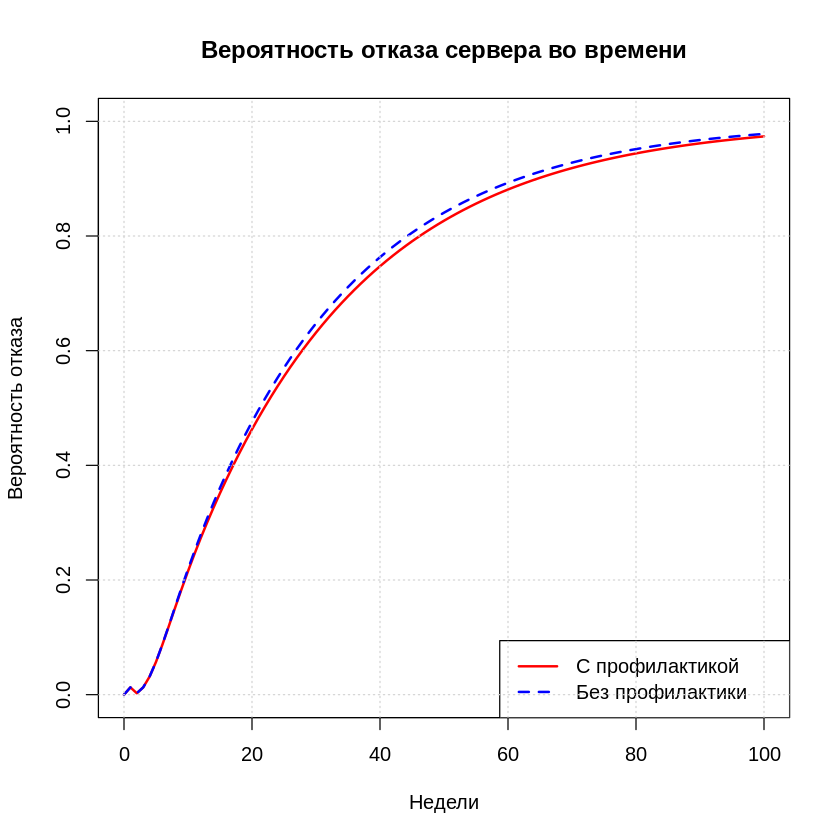

In [ ]:
# Построение графика динамики вероятностей

weeks_to_plot <- 100
time_points <- 0:weeks_to_plot

# Матрицы для хранения вероятностей по времени
probs_with_maint <- matrix(0, nrow = weeks_to_plot + 1, ncol = 6)
probs_no_maint <- matrix(0, nrow = weeks_to_plot + 1, ncol = 5)

# Вычисляем для каждой недели
for (t in time_points) {
  if (t == 0) {
    probs_with_maint[t + 1, ] <- pi_0
    probs_no_maint[t + 1, ] <- c(1, 0, 0, 0, 0)
  } else {
    P_t <- matrix_power(P, t)
    P_t_no <- matrix_power(P_no_maint, t)
    probs_with_maint[t + 1, ] <- pi_0 %*% P_t
    probs_no_maint[t + 1, ] <- c(1, 0, 0, 0, 0) %*% P_t_no
  }
}

# Выводим график вероятности отказа во времени
plot(time_points, probs_with_maint[, 6], type = "l", col = "red", lwd = 2,
     xlab = "Недели", ylab = "Вероятность отказа",
     main = "Вероятность отказа сервера во времени",
     ylim = c(0, 1))
lines(time_points, probs_no_maint[, 5], col = "blue", lwd = 2, lty = 2)
legend("bottomright", legend = c("С профилактикой", "Без профилактики"),
       col = c("red", "blue"), lwd = 2, lty = c(1, 2))
grid()

Профилактика увеличивает MTTF. Профилактика работает как механизм восстановления сервера, то есть:
1) из S3 (удовлетворительное): вероятность p_35=0.15  приводит к полному восстановлению с вероятностью 0.85 или частичному с 0.15.
2) из S4 (критическое): вероятность p_45=0.30  спасает сервер от неизбежного отказа p_46=0.20

## Задание 2. Одноканальная СМО


In [ ]:
# Параметры системы

k <- 13          # число программистов (> 10)
t1 <- 35         # среднее время подготовки программы (мин)
t2 <- 2          # среднее время выполнения на сервере (мин)

lambda <- 1 / t1 # интенсивность подготовки
mu <- 1 / t2     # интенсивность обслуживания

cat("Параметры системы:\n")
cat("k =", k, "программистов\n")
cat("t1 =", t1, "мин, lambda =", round(lambda, 4), "1/мин\n")
cat("t2 =", t2, "мин, mu =", round(mu, 4), "1/мин\n")
cat("Нагрузка y = lambda/mu =", round(lambda/mu, 4), "\n")

Параметры системы:
k = 13 программистов
t1 = 35 мин, lambda = 0.0286 1/мин
t2 = 2 мин, mu = 0.5 1/мин
Нагрузка y = lambda/mu = 0.0571 


### Режим 1 — замкнутая СМО (программист ждёт ответа)


***Модель "гибели и размножения"***

$$P_0=\left(1+\sum_{k=1}^n\frac{\prod_{i=1}^k\lambda_i}{\prod_{i=1}^k \mu_i}\right)^{-1}\tag{3.6 из лек}$$

In [ ]:
p0 <- 1  # вероятность состояния 0 (нормировка)
prob_sum <- 1

# Вычисляем ненормированные вероятности
for (n in 1:k) {
  # Произведение интенсивностей поступления / интенсивностей обслуживания
  prod_term <- 1
  for (i in 0:(n-1)) {
    prod_term <- prod_term * ((k - i) * lambda) / mu
  }
  p0 <- c(p0, prod_term)
  prob_sum <- prob_sum + prod_term
}

# Нормируем
p_closed <- p0 / prob_sum

cat("Режим 1: Замкнутая СМО\n")
cat("Вероятности состояний (0 заявок ... k заявок):\n")
cat(round(p_closed, 6), "\n")
cat("Сумма вероятностей:", sum(p_closed), "\n")

Режим 1: Замкнутая СМО
Вероятности состояний (0 заявок ... k заявок):
0.342729 0.254599 0.174582 0.109737 0.062707 0.032249 0.014743 0.005897 0.002022 0.000578 0.000132 2.3e-05 3e-06 0 
Сумма вероятностей: 1 


In [ ]:
# Характеристики режима 1 (замкнутая СМО)

P_wait_closed <- 1 - p_closed[1]  # P(n > 0) = 1 - P(n = 0)

# Коэффициент простоя (сервер свободен)
eta_closed <- p_closed[1]

# Среднее число заявок в системе, мат ожидание СДВ
L_closed <- sum((0:k) * p_closed)

# Интенсивность потока: lambda_eff = sum((k-n)*lambda * p_n)
lambda_eff_closed <- sum((k - (0:k)) * lambda * p_closed)

# Среднее время пребывания в системе (формула Литтла)
W_closed <- L_closed / lambda_eff_closed

# Среднее число заявок в очереди
Lq_closed <- sum(pmax(0, (0:k) - 1) * p_closed)


cat("\nХарактеристики режима 1:\n")
cat("P(ожидание) =", round(P_wait_closed, 4), "\n")
cat("Коэффициент простоя eta =", round(eta_closed, 4), "\n")
cat("L (среднее число заявок в системе) =", round(L_closed, 4), "\n")
cat("W (среднее время в системе) =", round(W_closed, 4), "мин\n")
cat("Lq (средняя длина очереди) =", round(Lq_closed, 4), "\n")



Характеристики режима 1:
P(ожидание) = 0.6573 
Коэффициент простоя eta = 0.3427 
L (среднее число заявок в системе) = 1.4978 
W (среднее время в системе) = 4.5575 мин
Lq (средняя длина очереди) = 0.8405 


In [ ]:
# Блок 1: Режим 1 — программист ждёт ответа от сервера

library(queueing)

model1 <- NewInput.MM1K(
  lambda = k * lambda / 2,
  mu = mu,
  k = k
)
result1 <- QueueingModel(model1)

print(names(result1))

cat("Режим 1: Программист ждёт ответа\n")

cat("Среднее число программ на сервере (L):", result1$L, "\n")
cat("Среднее время в системе (W):", result1$W, "мин\n")
cat("Пропускная способность:", result1$Throughput, "программ/мин\n")

 [1] "Inputs"     "RO"         "Lq"         "VNq"        "Wq"        
 [6] "VTq"        "Throughput" "L"          "VN"         "W"         
[11] "VTq"        "Wqq"        "Lqq"        "Pn"         "Qn"        
[16] "FW"         "FWq"       
Режим 1: Программист ждёт ответа
Среднее число программ на сервере (L): 0.6827239 
Среднее время в системе (W): 8.253469 мин
Пропускная способность: 0.08271963 программ/мин


In [ ]:
# Режим 2 — открытая СМО

lambda_open <- k * lambda
rho <- lambda_open / mu  # загрузка системы

cat("Интенсивность входного потока:", round(lambda_open, 4), "\n")
cat("Загрузка rho =", round(rho, 4), "\n")

if (rho >= 1) {
  cat("ВНИМАНИЕ: rho >= 1\n")
} else {
  cat("Система стационарна\n")
}

Интенсивность входного потока: 0.3714 
Загрузка rho = 0.7429 
Система стационарна


In [ ]:
# Характеристики режима 2


# Вероятность, что программа не выполнена сразу (сервер занят)
P_wait_open <- rho

# Среднее число заявок в системе
L_open <- rho / (1 - rho)

# Среднее время пребывания в системе (формула Литтла)
W_open <- L_open / lambda_open

# Среднее число заявок в очереди
Lq_open <- rho^2 / (1 - rho)

# Коэффициент простоя
eta_open <- 1 - rho

cat("\nХарактеристики режима 2:\n")
cat("P(ожидание) = rho =", round(P_wait_open, 4), "\n")
cat("L (среднее число заявок в системе) =", round(L_open, 4), "\n")
cat("W (среднее время в системе) =", round(W_open, 4), "мин\n")
cat("Lq (средняя длина очереди) =", round(Lq_open, 4), "\n")
cat("Коэффициент простоя eta =", round(eta_open, 4), "\n")



Характеристики режима 2:
P(ожидание) = rho = 0.7429 
L (среднее число заявок в системе) = 2.8889 
W (среднее время в системе) = 7.7778 мин
Lq (средняя длина очереди) = 2.146 
Коэффициент простоя eta = 0.2571 


In [ ]:
# Имитационное моделирование режима 1

set.seed(123)  # для воспроизводимости

simulate_mm1_closed <- function(k, lambda, mu, simulation_time = 10000) {
  # Событийное моделирование замкнутой СМО

  # Состояние: число заявок в системе
  n <- 0

  # Время
  t <- 0

  # Статистика
  total_time <- 0
  total_arrivals <- 0
  total_served <- 0
  time_in_states <- numeric(k + 1)

  # Следующие события
  next_arrival <- rexp(1, k * lambda)  # первое поступление
  next_departure <- Inf

  while (t < simulation_time) {
    # Определяем ближайшее событие
    if (next_arrival < next_departure) {
      # Поступление
      dt <- next_arrival - t
      time_in_states[n + 1] <- time_in_states[n + 1] + dt

      t <- next_arrival
      n <- n + 1
      total_arrivals <- total_arrivals + 1

      # Если сервер был свободен, начинаем обслуживание
      if (n == 1) {
        next_departure <- t + rexp(1, mu)
      }

      # Следующее поступление (если есть свободные программисты)
      if (n < k) {
        next_arrival <- t + rexp(1, (k - n) * lambda)
      } else {
        next_arrival <- Inf  # все программисты ждут
      }

    } else {
      # Завершение обслуживания
      dt <- next_departure - t
      time_in_states[n + 1] <- time_in_states[n + 1] + dt

      t <- next_departure
      n <- n - 1
      total_served <- total_served + 1

      if (n > 0) {
        next_departure <- t + rexp(1, mu)
      } else {
        next_departure <- Inf
      }

      # Теперь есть свободный программист
      if (n < k - 1) {
        next_arrival <- t + rexp(1, (k - n) * lambda)
      }
    }
  }

  # Финальные вероятности (доля времени в каждом состоянии)
  p_sim <- time_in_states / simulation_time

  return(list(
    p = p_sim,
    L = sum((0:k) * p_sim),
    lambda_eff = total_served / simulation_time,
    eta = p_sim[1]
  ))
}

cat("Имитационное моделирование (режим 1)\n")
sim_result <- simulate_mm1_closed(k, lambda, mu, 50000)

cat("Симуляционные вероятности состояний:\n")
cat(round(sim_result$p, 6), "\n")

cat(sprintf("L (теория) = %.4f, L (симуляция) = %.4f\n",
            L_closed, sim_result$L))
cat(sprintf("eta (теория) = %.4f, eta (симуляция) = %.4f\n",
            eta_closed, sim_result$eta))

Имитационное моделирование (режим 1)
Симуляционные вероятности состояний:
0.344029 0.252685 0.171516 0.112319 0.06234 0.033206 0.015424 0.005855 0.001709 0.000636 0.000262 2.3e-05 0 0 
L (теория) = 1.4978, L (симуляция) = 1.5039
eta (теория) = 0.3427, eta (симуляция) = 0.3440


In [ ]:
# Режим 2 — программист сразу пишет новую программу

library(queueing)

lambda_total <- k * lambda

model2 <- NewInput.MM1(
  lambda = lambda_total,
  mu = mu,
  n = 0
)

result2 <- QueueingModel(model2)

cat("Вероятность ожидания:", round(result2$RO, 4), "\n")
cat("Среднее число программ на сервере:", round(result2$L, 4), "\n")
cat("Среднее время в системе:", round(result2$W, 4), "мин\n")
cat("Средняя длина очереди:", round(result2$Lq, 4), "\n")
cat("Коэффициент простоя сервера:", round(1 - result2$RO, 4), "\n")


Вероятность ожидания: 0.8333 
Среднее число программ на сервере: 5 
Среднее время в системе: 30 мин
Средняя длина очереди: 4.1667 
Коэффициент простоя сервера: 0.1667 
